# φ⁴ Hamiltonian Truncation on a Circle

Builds the truncated Hamiltonian for an interacting scalar field in 1+1D on a circle of radius $r$:

$$H_\text{raw} = H_0 + \frac{g}{24 \cdot r \cdot 8\pi}\,\delta H_4$$

$$H_\text{LO} = H_0 + \frac{1}{4} m_2^2 \,\delta H_2 + \frac{g+\lambda_2}{24 \cdot r \cdot 8\pi}\,\delta H_4$$

and studies how the energy gap $E_1^+ - E_0$ converges as the energy cutoff $E_\mathrm{max}\to\infty$.

Reference: arXiv:2507.15941


In [45]:
import math
import bisect
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as sp_linalg
from scipy.sparse import csr_matrix, identity
import matplotlib.pyplot as plt
from collections import Counter
import time
import csv
import matplotlib.ticker as ticker

%matplotlib inline

## 1. Single-particle energy and mode indexing

Modes are labelled by magnitude $l \ge 0$ (momentum $\pm l/r$) and sign $\sigma = \pm 1$.
States are stored as lists `[n₀, n₁₊, n₁₋, n₂₊, n₂₋, …]` where the helper `ix(l,σ)` gives the list index.


In [2]:
omega_list = []   # omega_list[l] = sqrt(l²/r² + m²)

def omega(l, m, r):
    """State Frequency"""
    return math.sqrt(float(l)*float(l)/(r*r) + m*m)

def gen_omega_list(lmax, m, r):
    global omega_list
    omega_list = [omega(l, m, r) for l in range(lmax + 1)]

def ix(l, sigma):
    """State-list index for mode (l, sigma)."""
    if l == 0: return 0
    return 2*l - 1 if sigma >= 0 else 2*l

def the_l(i):
    """Mode number from state-list index."""
    if i == 0: return 0
    return int((i+1)/2) if i % 2 != 0 else int(i/2)

def the_sigma(i):
    if i == 0: return 0
    return 1 if i % 2 != 0 else -1


## 2. Basis generation

`gen_basis` recursively builds all occupation-number states with energy ≤ `e_max`.
We then filter to the **zero-total-momentum** sector (`l_total == 0`) and optionally
to the **even-parity** sector (even total particle number).


In [138]:
def gen_coins(n_max):
    global coins
    #Creates the coins dictionary if it does not already exist.
    if 'coins' not in globals():
        coins = {}
        coins.setdefault(1,[[1]]) 
        
    #If we have already calculated up to n_max, just return the dictionary.
    if n_max in coins: return(coins)
     

    for i in range(max(coins.keys())+1,n_max+1):
        #This step is a little complicated so I'll break it down into the two parts of the sum:
        #   1. The first part adds [1] to the end of every list for the previous element (e.g. 6:[[6],...] -> 7:[...,[6, 1],...])
        #   2. The second part adds 1 to the final element of the previous interation (e.g. 6:[...,[3,2,1],...]->7:[...,[3,2,2],...]) given the following conditions:
        #       a) If the length of the dictionary is 1, just add one (i.e 6:[[6],..] -> 7:[[7],...])
        #       b) If the final two elements of a list are the same, there also exists one where the final two elements differ by two (e.g. 6:[...,[3,3],[4,2],...]).
        #          Without input, this would result in duplicate entries. Therefore, the final two elements must not be equal for this step.
        '''coins[i]=[]
        for coincomb in coins[i-1]:
            if (len(coincomb)==1 or coincomb[-2]!=coincomb[-1]):
                coins[i] += [coincomb[:-1]+[coincomb[-1]+1]]
                coins[i] += [coincomb + [1]]
            else:
                coins[i] += [coincomb + [1]]
          '''

        coins[i] = [cns[:-1]+[cns[-1]+1] for cns in coins[i-1] if (len(cns)==1 or cns[-2]!=cns[-1])] + list(map(lambda x:x+[1], coins[i-1])) 
        coins[i] = sorted(coins[i], key=len) #May be a smarter way to do this?
        print(f'Total {coins[i]}')
    return coins

def coin_dict():
    #Turns above into a counting dictionary
    global coinDict
    coinDict = {}
    for key in coins.keys():
        coinDict[key] = [Counter(val) for val in coins[key]]
        
def coin_energies(l,m,r):
    #Computes the energies of each possible change.
    return [sum(map(lambda c: omega(c, m, r), change)) for change in coins[l]]
    
            

In [140]:
del coins

In [141]:
gen_coins(7)
for i in range(1,8):
    print(f'lmax = {i}')
    for change in coins[i]:
        print(f'Coins = {change}, Energy = {sum(map(lambda c: omega(c, 1, 1), change))}')

Total [[2], [1, 1]]
Total [[3], [2, 1], [1, 1, 1]]
Total [[4], [2, 2], [3, 1], [2, 1, 1], [1, 1, 1, 1]]
Total [[5], [3, 2], [4, 1], [2, 2, 1], [3, 1, 1], [2, 1, 1, 1], [1, 1, 1, 1, 1]]
Total [[6], [3, 3], [4, 2], [5, 1], [2, 2, 2], [3, 2, 1], [4, 1, 1], [2, 2, 1, 1], [3, 1, 1, 1], [2, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1]]
Total [[7], [4, 3], [5, 2], [6, 1], [3, 2, 2], [3, 3, 1], [4, 2, 1], [5, 1, 1], [2, 2, 2, 1], [3, 2, 1, 1], [4, 1, 1, 1], [2, 2, 1, 1, 1], [3, 1, 1, 1, 1], [2, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1]]
lmax = 1
Coins = [1], Energy = 1.4142135623730951
lmax = 2
Coins = [2], Energy = 2.23606797749979
Coins = [1, 1], Energy = 2.8284271247461903
lmax = 3
Coins = [3], Energy = 3.1622776601683795
Coins = [2, 1], Energy = 3.6502815398728847
Coins = [1, 1, 1], Energy = 4.242640687119286
lmax = 4
Coins = [4], Energy = 4.123105625617661
Coins = [2, 2], Energy = 4.47213595499958
Coins = [3, 1], Energy = 4.576491222541475
Coins = [2, 1, 1], Energy = 5.06449510224598
Coins = [1, 1, 1, 1],

In [104]:
def gen_basis(lmax, e_max, m, r):
    result = []
    #l=0:
    result += [{0: i} for i in range(0, int(math.floor(e_max/m)) + 1)]    
    #l>0:
    for l in range(1,lmax+1):
        gen_coins(l) #All ways of making up to lmax with smaller numbers
        coin_dict()
        coinEnergies = coin_energies(l,m,r)

        for ii,ci in enumerate(coinDict[l]):
            for jj,cj in enumerate(coinDict[l]):
                #Build a temporary energy for the state
                e_temp = e_max - coinEnergies[ii] - coinEnergies[jj]
                if e_temp > 0: #Fill up l=0 state up to e_max.
                    cicjDict = ci | {-jjj:cjj for jjj,cjj in cj.items()}
                    result += [cicjDict]
                    result += [{0: i} | cicjDict for i in range(1, int(math.floor(e_temp/m)) + 1)]
                
    return result

In [105]:
def effective_lmax(lmax, e_max, m, r):
    if m**2 < e_max**2 / 4:
        return int(min(lmax, math.floor(math.sqrt(max(0, r**2*(e_max**2/4 - m**2))))))
    return 0

In [106]:
m = 1; r = 10/(2*math.pi)
execution_times = []; len_basis = []

emax_list = range(6,20)

for emax in emax_list:
    start_time = time.perf_counter()
    lmaxeff = effective_lmax(emax,emax,m,r)
    basis = gen_basis(lmaxeff,emax,m,r)  # Execute the function
    
    end_time = time.perf_counter()
    duration = end_time - start_time
    execution_times.append(duration)
    len_basis.append(len(basis))
    
    del coins #For fairness, reset the coins dictionary each time.
    
    print(f"E_max: {emax} | Time: {duration:.6f} seconds")

csv_filename = "benchmark_results.csv"
execution_times_old = []
with open(csv_filename, mode="r") as file:
    reader = csv.reader(file)
    next(reader)  # Skip the header row
    
    for row in reader:
        execution_times_old.append(float(row[1])) # Convert time back to float


# 4. Plot the results
fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.set_xlabel(r'$E_\text{max}$', color='black')
ax1.set_ylabel('Time in Seconds (Log Scale)')
ax1.set_yscale('log')
ax1.tick_params(axis='x', labelcolor='black')
ax1.grid(True, which="both", linestyle='--', alpha=0.5)

ax1.plot(emax_list, execution_times, marker='o', linestyle='-', color='b', label='New Method')
ax1.plot(emax_list, execution_times_old, marker ='o', linestyle='-', color='r', label='Old Method')


coef_new = (np.polyfit(emax_list[1:], np.log10(execution_times)[1:], 1))
coef_old = (np.polyfit(emax_list[1:], np.log10(execution_times_old)[1:], 1))
poly_new = np.poly1d(coef_new)
poly_old = np.poly1d(coef_old)
xs = np.linspace(emax_list[1],emax_list[-1])

ax1.plot(xs, 10**poly_new(xs), linestyle='--', color='b', label=f'New Fit $log(t)={coef_new[0]:.1f}x+{coef_new[1]:.1f}$')
ax1.plot(xs, 10**poly_old(xs), linestyle='--', color='r', label=f'Old Fit $log(t)={coef_old[0]:.1f}x+{coef_old[1]:.1f}$')
ax1.legend()


ax2 = ax1.twiny() 
ax2.set_xlim(ax1.get_xlim())
ax2.set_xticks(emax_list) 

formatted_top_labels = []
for x in len_basis:
    if x>10000:
        base, exponent = f"{x:.0e}".split("e")
        # Clean up the sign on the exponent (e.g., +06 becomes 6)
        exponent = int(exponent) 
        # Wrap in LaTeX math style for true superscripts
        formatted_top_labels.append(f"${base} \\times 10^{{{exponent}}}$")
    else:
        formatted_top_labels.append(x)
    
ax2.set_xticklabels(formatted_top_labels) 
ax2.set_xlabel('Basis Length', color='blue')
ax2.tick_params(axis='x', labelcolor='blue')


plt.title(r'Function Execution Time vs $E_\text{max}$')
plt.show()


Total [[], [1, 1], [2]]


IndexError: list index out of range

Total [[1, 1], [2]]
Total [[1, 1, 1], [2, 1], [3]]
Total [[1, 1, 1, 1], [2, 1, 1], [3, 1], [2, 2], [4]]
Total [[1, 1, 1, 1, 1], [2, 1, 1, 1], [3, 1, 1], [2, 2, 1], [4, 1], [3, 2], [5]]


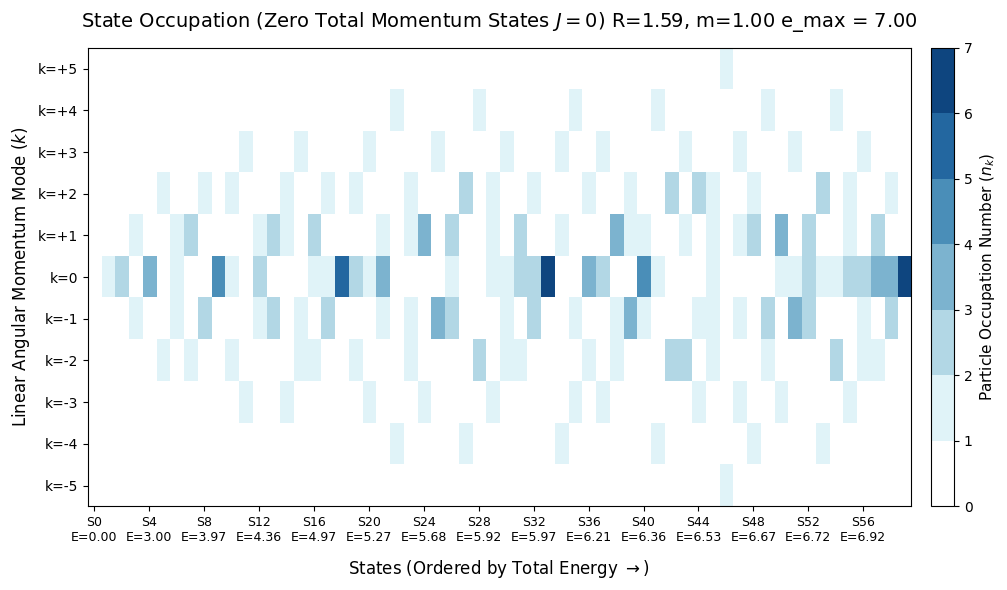

In [43]:
m = 1; r = 10/(2*math.pi); e_max=7; lmaxeff = effective_lmax(e_max,e_max,m,r)
basis = gen_basis(lmaxeff,e_max,m,r)

from matplotlib.colors import ListedColormap
# -- Mode Range and J=0 Basis for Plot ---

lrange = lmaxeff
_basis = basis

#Possible Angular Momenta
modes = list(range(-lrange, lrange+1))


# --- Sort states by physical free energies (E = sum(sqrt(1 + k^2))) ---
sorted_states = []
state_energies = []
for state in _basis:
    state_energies.append(sum([nl*omega(l, m, r) for l, nl in state.items()]))
    
sorted_states=[x for x, _ in sorted(zip(basis, state_energies), key=lambda pair: pair[1])]
sorted_energies=sorted(state_energies)

# --- Construct the Linear Grid Matrix ---
grid_matrix = np.zeros((len(modes), len(sorted_states)))
for col_idx, stateDict in enumerate(sorted_states):
    grid_matrix[:, col_idx] = [stateDict[x] if x in stateDict else 0 for x in modes]


# --- Plotting the Grid Heatmap ---
fig, ax = plt.subplots(figsize=(11, 6))

#DISCRETE COLOUR MAP:
blue_gradient = [
    '#ffffff', '#e0f3f8', '#b2d7e5', '#7cb3cf', '#4a8eb8',
    '#2367a0', '#0e457f', '#022659', '#001035', '#000314'
]
blue_cmap = ListedColormap(blue_gradient[:int(max(np.ndarray.flatten(grid_matrix)))])
# origin='lower' keeps negative momentum at the bottom and positive at the top
cax = ax.imshow(grid_matrix, cmap=blue_cmap, aspect='auto', origin='lower',interpolation='nearest')

# Axis Configuration (Y-Axis: Momentum)
mode_labels = [f"k={m}" if m <= 0 else f"k=+{m}" for m in modes]
ax.set_yticks(np.arange(len(modes)))
ax.set_yticklabels(mode_labels, fontsize=10)
ax.set_ylabel("Linear Angular Momentum Mode ($k$)", fontsize=12)

# Axis Configuration (X-Axis: Energy Sorted States)
state_labels = [f"S{i}\nE={item:.2f}" for i, item in enumerate(sorted_energies)]
if len(state_labels)>15:
    _state_labels=state_labels[::int(math.ceil(len(state_labels)/15))]

ax.set_xticks(np.arange(0,len(sorted_states),int(math.ceil(len(state_labels)/15))))
ax.set_xticklabels(_state_labels, fontsize=9)
ax.set_xlabel("States (Ordered by Total Energy $\\rightarrow$)", fontsize=12, labelpad=10)

ax.set_title(f"State Occupation (Zero Total Momentum States $J=0$) R={r:.2f}, m={m:.2f} e_max = {e_max:.2f}", fontsize=14, pad=15)

# Setup a clean discrete colorbar for occupation levels
max_occ = int(np.max(grid_matrix))
cbar = fig.colorbar(cax, ax=ax, ticks=np.arange(max_occ + 1), pad=0.02)
cbar.set_label('Particle Occupation Number ($n_k$)', fontsize=11)

plt.grid(False) # Turn off the default global grid overlay to keep image clean
plt.tight_layout()
plt.show()

In [102]:
import seaborn as sns

# -- Mode Range and J=0 Basis for Plot ---
lrange = lmaxeff 
_basis = basis

#Possible Angular Momenta
modes = list(range(-lrange, lrange+1))

# --- Generate Raw Hamiltonian Matrix ---
H_total = np.ones((len(sorted_states), len(sorted_states)))

#We can figure out which transitions between states are allowed by calculating the Hamming distance
for ii, si in enumerate(sorted_states):
    for jj, sj in enumerate(sorted_states):
        if ii == jj:
            H_total[ii,jj]=1
        else:
            diff = np.array(set(si)^set(sj))
            print(diff)
            if len(diff)>0:
                print(np.array(set(si)^set(sj))[:,1])
                if sum(np.array(set(si)^set(sj))[:,1])==4: #Hamming Distance Checker
                    H_total[ii,jj]=1

# --- State labels ---
verbose_labels = []

for state in sorted_states:
    verbose_labels.append("{"+", ".join(f"{key}: {value}" for key, value in state.items() if value !=0)+"}")


# --- Plotting the Heatmap Matrix ---
plt.figure(figsize=(11, 9))

zero_mask = (H_total == 0.0)
ax = sns.heatmap(
    H_total, 
    annot=True, 
    fmt=".2f", 
    cmap="magma", 
    linewidths=0.8,
    xticklabels=verbose_labels, 
    yticklabels=verbose_labels,
    mask=zero_mask,
    cbar_kws={'label': 'Matrix Element Magnitude $\\langle \\psi_{out} | H | \\psi_{in} \\rangle$'}
)

'''#Adding 0.00 to the zero entries for clarity.
for y in range(H_sorted.toarray().shape[0]):
    for x in range(H_sorted.toarray().shape[1]):
        if zero_mask[y, x]:
            ax.text(
                x + 0.5, y + 0.5, '0.00',     # Centering coordinates inside the grid cell
                ha='center', va='center',    # Direct spatial centering properties
                color='gray',                # Uses a muted color so it doesn't distract from the real data
                fontsize=9,                  # Match or slightly shrink font size
                fontweight='light'
            )'''


ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')
ax.set_facecolor('#eaeaea') # Soft gray for zero elements
plt.xticks(rotation=45, ha='left', fontsize=9)
plt.yticks(rotation=0, fontsize=9)

plt.title(rf"2D $\phi^4$ Raw Hamiltonian Matrix Heatmap with Occupation Tracking, R={r}, m={m} e_max = {e_max}", fontsize=13, pad=60)
plt.tight_layout()
plt.show()


set()


TypeError: len() of unsized object

In [ ]:
def make_basis(lmax, e_max, m, r):
    """Generate full basis and set omega_list as a side-effect."""
    global omega_list
    basis = gen_basis(lmax, e_max, m, r)
    gen_omega_list(lmax, m, r)
    basis.sort()
    return basis

def count_particles(state):
    return sum(state)

def l_total(state):
    """Total momentum in units of 1/r."""
    l_sum = 0
    for i in range(1, len(state)):
        if i % 2 != 0:
            l_sum += state[i] * the_l(i)
        else:
            l_sum -= state[i] * the_l(i)
    return l_sum

def state_energy(state, m, r):
    total = 0
    for i in range(len(state)):
        total += state[i] * omega_list[abs(the_l(i))]
    return total

def basis_l0(basis):    return [s for s in basis if l_total(s) == 0]
def basis_even(basis):  return [s for s in basis if sum(s) % 2 == 0]
def basis_odd(basis):   return [s for s in basis if sum(s) % 2 != 0]


def effective_lmax(lmax, e_max, m, r):
    """Modes above this cannot appear in zero-momentum states at energy e_max."""
    
    '''Note this equation is https://arxiv.org/pdf/2110.08273 Eq. (5.5), and maybe the relevant discussion of the 'quantisation mass' on Pg. (40) 
    of this paper and Eq. (B.3) of https://arxiv.org/pdf/2507.15941. However, note for future self: I am a little confused by the factors here.'''

    if m**2 < e_max**2 / 4:
        return int(min(lmax, math.floor(math.sqrt(max(0, r**2*(e_max**2/4 - m**2))))))
    return 0


## 3. Hamiltonian operators

Each function below builds a sparse matrix for a specific combination of raising ($a^\dagger$) and lowering ($a$) operators acting on the basis.

- `lower4` — annihilate 4 particles (contributes to $\delta H_4$)
- `raise1low3` — annihilate 3, create 1
- `raise2low2` — annihilate 2, create 2 (diagonal-block term)
- `lower2` — annihilate 2 particles (contributes to $\delta H_2$)
- `raise1low1` — annihilate 1, create 1 (diagonal term of $\delta H_2$)

The op-list functions enumerate all momentum-conserving mode combinations with the
correct symmetry factor, following arXiv:2507.15941 Eqs. (2.5)–(2.7).


In [ ]:
def lower4(l1,s1,l2,s2,l3,s3,l4,s4, e_max,m,r,basis):
    row,col,data = [],[],[]
    ix_max = len(basis[0])
    for state_index in range(len(basis)):
        pos = -1
        state = basis[state_index]
        norm = math.sqrt(state[ix(l1,s1)])
        if norm != 0:
            ns1 = [state[ix(l1,s1)]-1 if i==ix(l1,s1) else state[i] for i in range(ix_max)]
            norm *= math.sqrt(ns1[ix(l2,s2)])
            if norm != 0:
                ns2 = [ns1[ix(l2,s2)]-1 if i==ix(l2,s2) else ns1[i] for i in range(ix_max)]
                norm *= math.sqrt(ns2[ix(l3,s3)])
                if norm != 0:
                    ns3 = [ns2[ix(l3,s3)]-1 if i==ix(l3,s3) else ns2[i] for i in range(ix_max)]
                    norm *= math.sqrt(ns3[ix(l4,s4)])
                    if norm != 0:
                        ns4 = [ns3[ix(l4,s4)]-1 if i==ix(l4,s4) else ns3[i] for i in range(ix_max)]
                        if state_energy(ns4,m,r) <= e_max:
                            pos = bisect.bisect_left(basis, ns4)
        if pos != -1:
            row.append(state_index); col.append(pos); data.append(norm)
    return csr_matrix((data,(row,col)), shape=(len(basis),len(basis)))

def raise1low3(l1,s1,l2,s2,l3,s3,l4,s4, e_max,m,r,basis):
    # l4,s4 is the raising operator
    row,col,data = [],[],[]
    ix_max = len(basis[0])
    for state_index in range(len(basis)):
        pos = -1
        state = basis[state_index]
        norm = math.sqrt(state[ix(l1,s1)])
        if norm != 0:
            ns1 = [state[ix(l1,s1)]-1 if i==ix(l1,s1) else state[i] for i in range(ix_max)]
            norm *= math.sqrt(ns1[ix(l2,s2)])
            if norm != 0:
                ns2 = [ns1[ix(l2,s2)]-1 if i==ix(l2,s2) else ns1[i] for i in range(ix_max)]
                norm *= math.sqrt(ns2[ix(l3,s3)])
                if norm != 0:
                    ns3 = [ns2[ix(l3,s3)]-1 if i==ix(l3,s3) else ns2[i] for i in range(ix_max)]
                    norm *= math.sqrt(ns3[ix(l4,s4)]+1)
                    if norm != 0:
                        ns4 = [ns3[ix(l4,s4)]+1 if i==ix(l4,s4) else ns3[i] for i in range(ix_max)]
                        if state_energy(ns4,m,r) <= e_max:
                            pos = bisect.bisect_left(basis, ns4)
        if pos != -1:
            row.append(state_index); col.append(pos); data.append(norm)
    return csr_matrix((data,(row,col)), shape=(len(basis),len(basis)))

def raise2low2(l1,s1,l2,s2,l3,s3,l4,s4, e_max,m,r,basis):
    # l3,s3 and l4,s4 are raising
    row,col,data = [],[],[]
    ix_max = len(basis[0])
    for state_index in range(len(basis)):
        state = basis[state_index]
        pos = -1
        norm = math.sqrt(state[ix(l1,s1)])
        if norm != 0:
            ns1 = [state[ix(l1,s1)]-1 if i==ix(l1,s1) else state[i] for i in range(ix_max)]
            norm *= math.sqrt(ns1[ix(l2,s2)])
            if norm != 0:
                ns2 = [ns1[ix(l2,s2)]-1 if i==ix(l2,s2) else ns1[i] for i in range(ix_max)]
                norm *= math.sqrt(ns2[ix(l3,s3)]+1)
                if norm != 0:
                    ns3 = [ns2[ix(l3,s3)]+1 if i==ix(l3,s3) else ns2[i] for i in range(ix_max)]
                    norm *= math.sqrt(ns3[ix(l4,s4)]+1)
                    if norm != 0:
                        ns4 = [ns3[ix(l4,s4)]+1 if i==ix(l4,s4) else ns3[i] for i in range(ix_max)]
                        if ns4 == state:
                            pos = state_index
                        elif state_energy(ns4,m,r) <= e_max:
                            pos = bisect.bisect_left(basis, ns4)
        if pos != -1:
            row.append(state_index); col.append(pos); data.append(norm)
    return csr_matrix((data,(row,col)), shape=(len(basis),len(basis)))

def raise2low2(l1, s1, l2, s2, l3, s3, l4, s4, e_max, m, r, basis):
    # l3, s3 and l4, s4 are raising.
    row = []
    col = []
    data = []
    norm = 0
    ix_max = len(basis[0])
    length_basis = len(basis)
    pos = -1
    for state_index in range(length_basis):
        state=basis[state_index]
        norm = math.sqrt(state[ix(l1, s1)])
        if norm != 0:
            newstate = [state[ix(l1, s1)] - 1 if i == ix(l1, s1) else state[i] for i in range(ix_max)]
            norm = norm*math.sqrt(newstate[ix(l2, s2)])
            if norm != 0:
                newstate2 = [newstate[ix(l2, s2)] - 1 if i == ix(l2, s2) else newstate[i] for i in range(ix_max)]
                norm = norm*math.sqrt(newstate2[ix(l3, s3)]+1)
                if norm != 0:
                    newstate3 = [newstate2[ix(l3, s3)] + 1 if i == ix(l3, s3) else newstate2[i] for i in range(ix_max)]
                    norm = norm*math.sqrt(newstate3[ix(l4, s4)] + 1)
                    if norm != 0:
                        newstate4 = [newstate3[ix(l4, s4)] + 1 if i == ix(l4, s4) else newstate3[i] for i in range(ix_max)]
                        if newstate4==state:
                            pos = state_index
                        elif state_energy(newstate4, m, r) <= e_max:
                            pos = bisect.bisect_left(basis, newstate4)
        if pos != -1:
            row.append(state_index)
            col.append(pos)
            data.append(norm)
            pos=-1
    return csr_matrix((data, (row, col)), shape=(length_basis, length_basis))

def lower2(l1,s1,l2,s2, e_max,m,r,basis):
    row,col,data = [],[],[]
    ix_max = len(basis[0])
    for state_index in range(len(basis)):
        pos = -1
        state = basis[state_index]
        norm = math.sqrt(state[ix(l1,s1)])
        if norm != 0:
            ns1 = [state[ix(l1,s1)]-1 if i==ix(l1,s1) else state[i] for i in range(ix_max)]
            norm *= math.sqrt(ns1[ix(l2,s2)])
            if norm != 0:
                ns2 = [ns1[ix(l2,s2)]-1 if i==ix(l2,s2) else ns1[i] for i in range(ix_max)]
                if state_energy(ns2,m,r) <= e_max:
                    pos = bisect.bisect_left(basis, ns2)
        if pos != -1:
            row.append(state_index); col.append(pos); data.append(norm)
    return csr_matrix((data,(row,col)), shape=(len(basis),len(basis)))

def raise1low1(l1,s1,l2,s2, e_max,m,r,basis):
    row,col,data = [],[],[]
    ix_max = len(basis[0])
    for state_index in range(len(basis)):
        pos = -1
        state = basis[state_index]
        norm = math.sqrt(state[ix(l1,s1)])
        if norm != 0:
            ns1 = [state[ix(l1,s1)]-1 if i==ix(l1,s1) else state[i] for i in range(ix_max)]
            norm *= math.sqrt(ns1[ix(l2,s2)]+1)
            if norm != 0:
                ns2 = [ns1[ix(l2,s2)]+1 if i==ix(l2,s2) else ns1[i] for i in range(ix_max)]
                if ns2 == state:
                    pos = state_index
                elif state_energy(ns2,m,r) <= e_max:
                    pos = bisect.bisect_left(basis, ns2)
        if pos != -1:
            row.append(state_index); col.append(pos); data.append(norm)
    return csr_matrix((data,(row,col)), shape=(len(basis),len(basis)))

In [ ]:
# Each function returns a list of [momenta, symmetry_factor] pairs
# covering all momentum-conserving 4-mode combinations (with no double-counting).

def raise4_op_list(lmax, e_max, m, r):
    global omega_list
    op_list = []
    for j in range(-lmax, lmax-2):
        for k in range(j+1, lmax-1):
            for l in range(k+1, lmax):
                n = -l-k-j
                if n in range(l+1,lmax+1) and omega_list[abs(j)]+omega_list[abs(k)]+omega_list[abs(l)]+omega_list[abs(n)] <= e_max:
                    op_list.append([[j,k,l,n], 24])
    for j in range(-lmax, lmax-1):
        for k in range(j+1, lmax):
            if (-k-j)%2==0:
                l = int((-k-j)/2)
                if l in range(k+1,lmax+1) and omega_list[abs(j)]+omega_list[abs(k)]+2*omega_list[abs(l)] <= e_max:
                    op_list.append([[j,k,l,l], 12])
    for j in range(-lmax, lmax-1):
        for k in range(j+1, lmax):
            l = -2*k-j
            if l in range(k+1,lmax+1) and omega_list[abs(j)]+2*omega_list[abs(k)]+omega_list[abs(l)] <= e_max:
                op_list.append([[j,k,k,l], 12])
    for j in range(-lmax, lmax-1):
        for k in range(j+1, lmax):
            l = -k-2*j
            if l in range(k+1,lmax+1) and 2*omega_list[abs(j)]+omega_list[abs(k)]+omega_list[abs(l)] <= e_max:
                op_list.append([[j,j,k,l], 12])
    for k in range(-lmax, lmax):
        l = -k
        if l in range(k+1,lmax+1) and 2*omega_list[abs(k)]+2*omega_list[abs(l)] <= e_max:
            op_list.append([[k,k,l,l], 6])
    for j in range(-lmax, lmax):
        if j%3==0:
            l = int(-j/3)
            if l in range(j+1,lmax+1) and omega_list[abs(j)]+3*omega_list[abs(l)] <= e_max:
                op_list.append([[j,l,l,l], 4])
    for j in range(-lmax, lmax):
        k = -3*j
        if k in range(j+1,lmax+1) and 3*omega_list[abs(j)]+omega_list[abs(k)] <= e_max:
            op_list.append([[j,j,j,k], 4])
    op_list.append([[0,0,0,0], 1])
    return op_list

def raise31_op_list(lmax, e_max, m, r):
    global omega_list
    op_list = []
    for j in range(-lmax, lmax-1):
        for k in range(j+1, lmax):
            for l in range(k+1, lmax+1):
                n = l+k+j
                if n in range(-lmax,lmax+1) and omega_list[abs(j)]+omega_list[abs(k)]+omega_list[abs(l)] <= e_max and omega_list[abs(n)] <= e_max:
                    op_list.append([[j,k,l,n], 6])
    for j in range(-lmax, lmax):
        for k in range(j+1, lmax+1):
            n = j+2*k
            if n in range(-lmax,lmax+1) and omega_list[abs(j)]+2*omega_list[abs(k)] <= e_max and omega_list[abs(n)] <= e_max:
                op_list.append([[j,k,k,n], 3])
    for k in range(-lmax, lmax):
        for l in range(k+1, lmax+1):
            n = 2*k+l
            if n in range(-lmax,lmax+1) and 2*omega_list[abs(k)]+omega_list[abs(l)] <= e_max and omega_list[abs(n)] <= e_max:
                op_list.append([[k,k,l,n], 3])
    for k in range(math.ceil(-lmax/3), math.floor(lmax/3)+1):
        n = 3*k
        if n in range(-lmax,lmax+1) and 3*omega_list[abs(k)] <= e_max and omega_list[abs(n)] <= e_max:
            op_list.append([[k,k,k,n], 1])
    return op_list

def raise22_op_list(lmax, e_max, m, r):
    global omega_list
    op_list = []
    for j in range(-lmax, lmax):
        for k in range(j+1, lmax+1):
            for l in range(-lmax, lmax):
                n = -l+k+j
                if n in range(l+1,lmax+1) and omega_list[abs(j)]+omega_list[abs(k)] <= e_max and omega_list[abs(l)]+omega_list[abs(n)] <= e_max:
                    op_list.append([[j,k,l,n], 4])
    for j in range(-lmax, lmax):
        for k in range(j+1, lmax+1):
            if (k+j)%2==0:
                l = int((k+j)/2)
                if l in range(-lmax,lmax+1) and omega_list[abs(j)]+omega_list[abs(k)] <= e_max and 2*omega_list[abs(l)] <= e_max:
                    op_list.append([[j,k,l,l], 2])
    for l in range(-lmax, lmax):
        for n in range(l+1, lmax+1):
            if (l+n)%2==0:
                k = int((l+n)/2)
                if k in range(-lmax,lmax+1) and 2*omega_list[abs(k)] <= e_max and omega_list[abs(l)]+omega_list[abs(n)] <= e_max:
                    op_list.append([[k,k,l,n], 2])
    for k in range(-lmax, lmax+1):
        if 2*omega_list[abs(k)] <= e_max:
            op_list.append([[k,k,k,k], 1])
    return op_list

def raise2_op_list(lmax, e_max, m, r):
    global omega_list
    op_list = []
    for i in range(-lmax, 0):
        if 2*omega_list[abs(i)] <= e_max:
            op_list.append([[i,-i], 2])
    op_list.append([[0,0], 1])
    return op_list

def raise11_op_list(lmax):
    return [[[i,i], 1] for i in range(-lmax, lmax+1)]

## 4. Assembling H₀, δH₂, δH₄

**H₀** (arXiv:2507.15941 Eq. 2.4): diagonal free-field energy.

**δH₄** (Eq. 2.5): the φ⁴ four-point interaction, assembled from all raising/lowering combinations.

**δH₂** (Eq. 2.7): mass counterterm — used for the LO corrections to the Hamiltonian (`delta_m ≠ 0`).


In [ ]:
def h0(lmax, e_max, m, r, basis):
    n = len(basis)
    data = [state_energy(basis[i], m, r) for i in range(n)]
    return csr_matrix((data, (range(n), range(n))), shape=(n,n))

def term_4low(lmax, e_max, m, r, basis):
    global omega_list
    length_basis=len(basis)
    total_op = csr_matrix(([], ([], [])), shape=(length_basis, length_basis))
    op_list = raise4_op_list(lmax, e_max, m, r)
    for op in op_list:
        i = op[0][0]
        j = op[0][1]
        l = op[0][2]
        k = op[0][3]
        new_op = lower4(int(abs(k)), np.sign(k), int(abs(l)), np.sign(l), int(abs(j)), np.sign(j), int(abs(i)), np.sign(i), e_max, m, r, basis)
        if new_op.count_nonzero() != 0:
            factor = op[1]/math.sqrt(omega_list[abs(i)] * omega_list[abs(j)] * omega_list[abs(l)] * omega_list[abs(k)])
            total_op = total_op+factor*new_op
    return total_op

def term_1raise3low(lmax, e_max, m, r, basis):
    global omega_list
    length_basis = len(basis)
    total_op = csr_matrix(([], ([], [])), shape=(length_basis, length_basis))
    op_list = raise31_op_list(lmax, e_max, m, r)
    for op in op_list:
        i = op[0][0]
        j = op[0][1]
        l = op[0][2]
        # k is the raising operator
        k = op[0][3]
        new_op = raise1low3(int(abs(i)), np.sign(i), int(abs(j)), np.sign(j), int(abs(l)), np.sign(l), int(abs(k)), np.sign(k), e_max, m, r, basis)
        if new_op.count_nonzero() != 0:
            factor = 4 * op[1] / math.sqrt(omega_list[abs(i)] * omega_list[abs(j)] * omega_list[abs(l)] * omega_list[abs(k)])
            total_op = total_op + factor * new_op
    return total_op

def term_2raise2low(lmax, e_max, m, r, basis):
    global omega_list
    length_basis=len(basis)
    total_op = csr_matrix(([], ([], [])), shape=(length_basis, length_basis))
    op_list = raise22_op_list(lmax, e_max, m, r)
    for op in op_list:
        i = op[0][0]
        j = op[0][1]
        l = op[0][2]
        k = op[0][3]
        new_op = raise2low2(abs(k), np.sign(k), abs(l), np.sign(l), abs(j), np.sign(j), abs(i), np.sign(i), e_max, m, r, basis)
        if new_op.count_nonzero() != 0:
            factor = 6 * op[1] / math.sqrt(omega_list[abs(i)] * omega_list[abs(j)] * omega_list[abs(l)] * omega_list[abs(k)])
            total_op = total_op + factor * new_op
    return total_op


def term_2low(lmax, e_max, m, r, basis):
    global omega_list
    length_basis = len(basis)
    total_op = csr_matrix(([], ([], [])), shape=(length_basis, length_basis))
    op_list = raise2_op_list(lmax, e_max, m, r)
    for op in op_list:
        i = op[0][0]
        j = op[0][1]
        new_op = lower2(abs(j), np.sign(j), abs(i), np.sign(i), e_max, m, r, basis)
        if new_op.count_nonzero() != 0:
            factor = op[1]/math.sqrt(omega_list[abs(i)] * omega_list[abs(j)])
            total_op = total_op+factor*new_op
    return total_op


def term_1raise1low(lmax, e_max, m, r, basis):
    global omega_list
    row = []
    col = []
    data = []
    length_basis=len(basis)
    for state_index in range(length_basis):
        state = basis[state_index]
        row.append(state_index)
        col.append(state_index)
        factor = 0
        for i in range(len(state)):
            factor = factor + 2 * state[i] / omega_list[abs(the_l(i))]
        data.append(factor)
    return csr_matrix((data, (row, col)), shape=(length_basis, length_basis))


def delta_h4(lmax, e_max, m, r, basis):
    t4 = term_4low(lmax, e_max, m, r, basis)
    t3 = term_1raise3low(lmax, e_max, m, r, basis)
    return t4 + t4.T + term_2raise2low(lmax, e_max, m, r, basis) + t3 + t3.T

def delta_h2(lmax, e_max, m, r, basis): 
    t2 = term_2low(lmax, e_max, m, r, basis)
    return t2 + t2.T + term_1raise1low(lmax, e_max, m, r, basis)


### Leading Order Corrections to Hamiltonian

In [ ]:
def mv2_sq(e_max, m, r, g, l_uv):
    sum1=0
    sum2=0
    sum3=0
    for l1 in range(1, math.floor((l_uv-1)/2)+1):
        for l2 in range(l1+1,l_uv-l1+1):
            nmtr=np.heaviside(omega(l2, m, r)+omega(l1, m, r)+ omega(l1+l2, m, r) - e_max, 0)
            sum1+=nmtr/(omega(l2, m, r)*omega(l1, m, r)*omega(l1+l2, m, r)*(omega(l2, m, r)+omega(l1, m, r) + omega(l1+l2, m, r)))
    for l in range(1, l_uv+1):
        nmtr=np.heaviside(2*omega(l, m, r) + omega(2*l, m, r)-e_max, 0)
        sum2+=nmtr/(pow(omega(l, m, r), 2)*omega(2*l,m, r)*(2*omega(l, m, r)+ omega(2*l, m, r)))
        nmtr=np.heaviside(2*omega(l, m, r) + m-e_max, 0)
        sum3+=nmtr/(pow(omega(l, m, r), 2)*m*(2*omega(l, m, r)+ m))
    total = sum1/2 + (sum2+sum3)/4
    total = - pow(g, 2)/pow(2*math.pi*r, 2)* total
    return total

def lambda2(e_max, m, r, g, l_uv):
    sum=0
    for l in range(1, l_uv+1):
        nmtr=np.heaviside(2*omega(l, m, r)-e_max, 0)
        sum+=nmtr/pow(omega(l, m, r), 3)
    return -3*pow(g, 2)/ (8*math.pi*r)*sum

## 5. Diagonalization

For small matrices we use dense `eigvalsh`. For large ones we use a sparse shift-invert trick to find the `k` lowest eigenvalues without forming the dense matrix.

In [ ]:
def compute_eigenvalues(H, k):
    """Return the k lowest eigenvalues of sparse symmetric H."""
    n = H.shape[0]
    k = min(k, n)
    if k > n - 2:
        return sorted(np.linalg.eigvalsh(H.toarray()))[:k]
    # Shift by the matrix norm so eigs(..., which='LM') finds the most-negative eigenvalues of H
    norm = sp_linalg.norm(H)
    eigs = sp_linalg.eigs(H - norm*identity(n), k, which='LM')[0]
    return sorted((eigs.real + norm).tolist())


## 6. Quick example

Build `H_LO=H₀+(m^2/4)·H_2 +(g+\lambda_2/24)·H₄` and `H_raw = H₀ + (g/24)·H₄` for a single `E_max` and print the lowest eigenvalues.

In [ ]:
m, r, g = 1.0, 10/(2*math.pi), 4*math.pi
e_max = 5
l_uv=1000 #Wilsonian momentum cutoff far exceeding the energy scales we're modelling with H_eff.


lmaxeff = effective_lmax(e_max, e_max, m, r)
gen_omega_list(l_uv + 1, m, r)
basisShort = basis_l0(make_basis(lmaxeff, e_max, m, r))
basisLong = make_basis(lmaxeff, e_max, m, r)

print(basisLong)
print(len(basisLong))
print(basisShort)
print(len(basisShort))

[[0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 1], [0, 0, 0, 0, 0, 1, 0], [0, 0, 0, 0, 1, 0, 0], [0, 0, 0, 1, 0, 0, 0], [0, 0, 1, 0, 0, 0, 0], [0, 0, 1, 0, 0, 0, 1], [0, 0, 1, 0, 0, 1, 0], [0, 0, 1, 0, 1, 0, 0], [0, 0, 1, 1, 0, 0, 0], [0, 0, 2, 0, 0, 0, 0], [0, 1, 0, 0, 0, 0, 0], [0, 1, 0, 0, 0, 0, 1], [0, 1, 0, 0, 0, 1, 0], [0, 1, 0, 0, 1, 0, 0], [0, 1, 0, 1, 0, 0, 0], [0, 1, 1, 0, 0, 0, 0], [0, 2, 0, 0, 0, 0, 0], [1, 0, 0, 0, 0, 0, 0], [1, 0, 0, 0, 0, 0, 1], [1, 0, 0, 0, 0, 1, 0], [1, 0, 0, 0, 1, 0, 0], [1, 0, 0, 1, 0, 0, 0], [1, 0, 1, 0, 0, 0, 0], [1, 0, 1, 0, 0, 0, 1], [1, 0, 1, 0, 0, 1, 0], [1, 0, 1, 0, 1, 0, 0], [1, 0, 1, 1, 0, 0, 0], [1, 0, 2, 0, 0, 0, 0], [1, 1, 0, 0, 0, 0, 0], [1, 1, 0, 0, 0, 0, 1], [1, 1, 0, 0, 0, 1, 0], [1, 1, 0, 0, 1, 0, 0], [1, 1, 0, 1, 0, 0, 0], [1, 1, 1, 0, 0, 0, 0], [1, 2, 0, 0, 0, 0, 0], [2, 0, 0, 0, 0, 0, 0], [2, 0, 0, 0, 0, 0, 1], [2, 0, 0, 0, 0, 1, 0], [2, 0, 0, 0, 1, 0, 0], [2, 0, 0, 1, 0, 0, 0], [2, 0, 1, 0, 0, 0, 0], [2, 0, 1, 0, 1, 0, 0], [2, 0, 1, 

In [ ]:
m, r, g = 1.0, 10/(2*math.pi), 4*math.pi
e_max = 8
l_uv=1000 #Wilsonian momentum cutoff far exceeding the energy scales we're modelling with H_eff.


lmaxeff = effective_lmax(e_max, e_max, m, r)
gen_omega_list(l_uv + 1, m, r)
basis = basis_l0(make_basis(lmaxeff, e_max, m, r))


basis.sort()
print(f'e_max={e_max}, lmaxeff={lmaxeff}, basis size={len(basis)}')

H0   = h0(lmaxeff, e_max, m, r, basis)
H2   = delta_h2(lmaxeff, e_max, m, r, basis)
H4   = (1/r)*(1/(8*math.pi)) * delta_h4(lmaxeff, e_max, m, r, basis)
H_raw = H0 + (g/24)*H4

H_LO = H0 + (1/4)*mv2_sq(e_max, m, r, g, l_uv)*H2 + 1/24*(g + lambda2(e_max, m, r, g, l_uv))*H4 #See https://arxiv.org/pdf/2507.15941 Eq. (2.43)


eigs_LO  = compute_eigenvalues(H_LO,  10)
eigs_raw = compute_eigenvalues(H_raw, 10)

print('\nLowest 10 Leading Order eigenvalues:', [f'{e:.4f}' for e in eigs_LO])
print('Lowest 10 Raw eigenvalues:', [f'{e:.4f}' for e in eigs_raw])
print(f'LO gap E1-E0:         {eigs_LO[1]-eigs_LO[0]:.6f}')
print(f'Raw gap E1-E0:        {eigs_raw[1]-eigs_raw[0]:.6f}')


UnboundLocalError: cannot access local variable 'result' where it is not associated with a value

### Look at basis occupancy plots:

In [ ]:
#Re-orders the states from angular momenta as (0, +1, -1, +2, -2, ...) to (..., -2, -1, 0, +1, +2, ...)
def sort_modes(state, lmaxeff):
    sorted_state = []
    # Iterate linearly from -lmaxeff to +lmaxeff
    for new_index in range(-lmaxeff, lmaxeff + 1):            
        original_index=(ix(abs(new_index),np.sign(new_index)))
            
        if original_index<len(state):
            sorted_state.append(state[original_index])
        else: sorted_state.append(0)

    return sorted_state

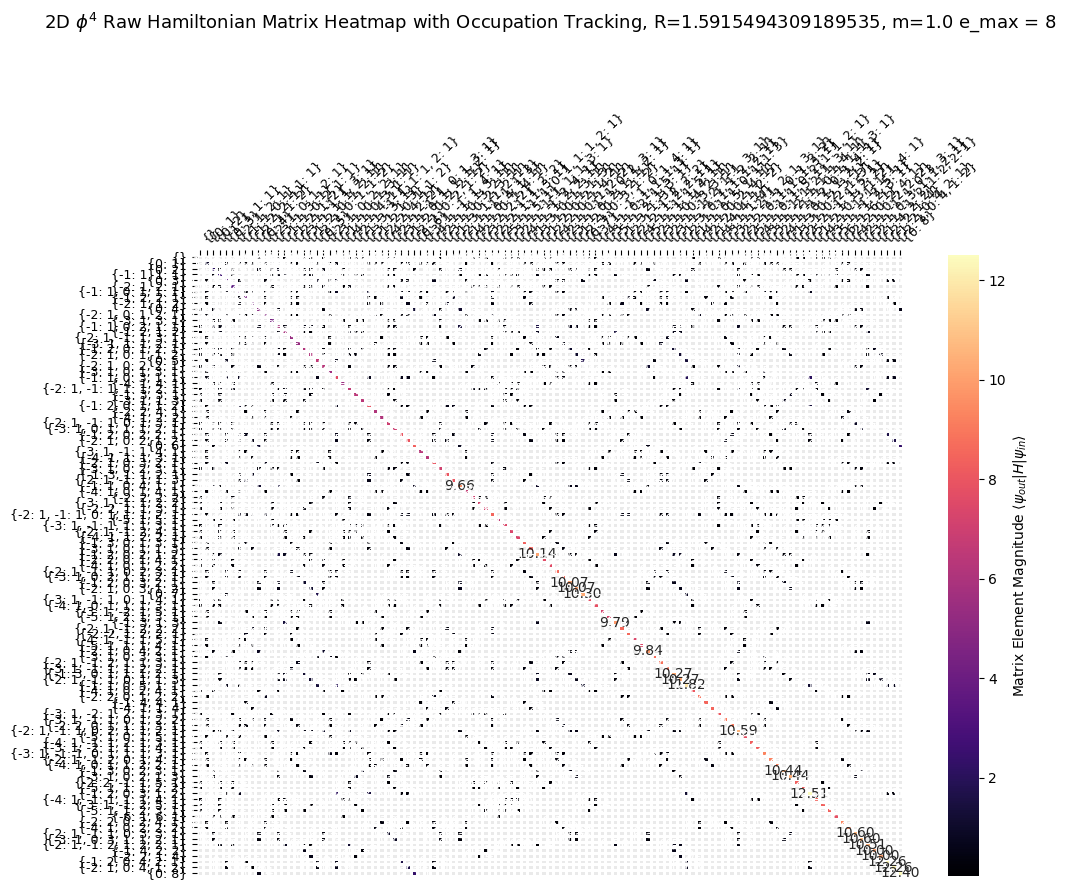

In [ ]:
import seaborn as sns

# -- Mode Range and J=0 Basis for Plot ---
lrange = lmaxeff 
_basis = basis

#Possible Angular Momenta
modes = list(range(-lrange, lrange+1))

# --- Generate Raw Hamiltonian Matrix (H_0 + V) ---
H_total = h0(lmaxeff,e_max,m,r,_basis) + (g/24)*(1/r)*(1/(8*math.pi))*delta_h4(lmaxeff,e_max,m,r,_basis)


# --- Sort states by physical free energies (E = sum(sqrt(1 + k^2))) ---
sorted_states = []
state_energies = []
for state in _basis:
    sorted_states.append(sort_modes(state, lrange))
    state_energies.append(state_energy(state,m,r))
    
sorted_states=[x for x, _ in sorted(zip(sorted_states, state_energies), key=lambda pair: pair[1])]
sort_indices = np.argsort(state_energies)
H_sorted = H_total[sort_indices, :][:, sort_indices]

# --- State labels ---
verbose_labels = []

for state in sorted_states:
    occ_vector = {k:state[i] for i,k in enumerate(modes)}
    verbose_labels.append("{"+", ".join(f"{key}: {value}" for key, value in occ_vector.items() if value !=0)+"}")


# --- Plotting the Heatmap Matrix ---
plt.figure(figsize=(11, 9))

zero_mask = (H_sorted.toarray() == 0.0)
ax = sns.heatmap(
    H_sorted.toarray(), 
    annot=True, 
    fmt=".2f", 
    cmap="magma", 
    linewidths=0.8,
    xticklabels=verbose_labels, 
    yticklabels=verbose_labels,
    mask=zero_mask,
    cbar_kws={'label': 'Matrix Element Magnitude $\\langle \\psi_{out} | H | \\psi_{in} \\rangle$'}
)

'''#Adding 0.00 to the zero entries for clarity.
for y in range(H_sorted.toarray().shape[0]):
    for x in range(H_sorted.toarray().shape[1]):
        if zero_mask[y, x]:
            ax.text(
                x + 0.5, y + 0.5, '0.00',     # Centering coordinates inside the grid cell
                ha='center', va='center',    # Direct spatial centering properties
                color='gray',                # Uses a muted color so it doesn't distract from the real data
                fontsize=9,                  # Match or slightly shrink font size
                fontweight='light'
            )'''


ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')
ax.set_facecolor('#eaeaea') # Soft gray for zero elements
plt.xticks(rotation=45, ha='left', fontsize=9)
plt.yticks(rotation=0, fontsize=9)

plt.title(rf"2D $\phi^4$ Raw Hamiltonian Matrix Heatmap with Occupation Tracking, R={r}, m={m} e_max = {e_max}", fontsize=13, pad=60)
plt.tight_layout()
plt.show()


## 7. Energy gap vs E_max at fixed volume

Scan `E_max` from 10 to 17 at fixed $r = 10/(2\pi)$, using the full zero-momentum basis.
We track the first energy gap $E_1 - E_0$ for both the raw theory (raw) and the Leading Order corrections (LO).

Raw error is expected to scale as $1/E_\text{Max}^2$ and LO as $1/E_\text{Max}^3$.


In [ ]:
m, r, g = 1.0, 10/(2*math.pi), 4*math.pi
n_eigens = 10
l_uv = 1000

scan_fixed = []
for e_max in range(8, 16): #Slightly larger emax gives better plots! Below seems like a bad fit.
    lmaxeff = effective_lmax(e_max, e_max, m, r)
    gen_omega_list(l_uv + 1, m, r)
    basis = basis_l0(make_basis(lmaxeff, e_max, m, r))
    basis.sort()

    H0   = h0(lmaxeff, e_max, m, r, basis)
    H2   = delta_h2(lmaxeff, e_max, m, r, basis)
    H4   = (1/r)*(1/(8*math.pi)) * delta_h4(lmaxeff, e_max, m, r, basis)
    H_raw = H0 + (g/24)*H4
    H_LO = H0 + (1/4)*mv2_sq(e_max, m, r, g, l_uv)*H2 + 1/24*(g + lambda2(e_max, m, r, g, l_uv))*H4 #See https://arxiv.org/pdf/2507.15941 Eq. (2.43)


    k = min(n_eigens, len(basis))
    eigs_raw = compute_eigenvalues(H_raw, k)
    eigs_LO = compute_eigenvalues(H_LO, k)
    scan_fixed.append({'e_max': e_max, 'eigs_raw': eigs_raw, 'eigs_LO': eigs_LO})
    print(f'e_max={e_max:2d}  lmaxeff={lmaxeff}  basis={len(basis)}')


e_max= 8  lmaxeff=6  basis=109
e_max= 9  lmaxeff=6  basis=199
e_max=10  lmaxeff=7  basis=359
e_max=11  lmaxeff=8  basis=620
e_max=12  lmaxeff=9  basis=1057
e_max=13  lmaxeff=10  basis=1788
e_max=14  lmaxeff=11  basis=2978
e_max=15  lmaxeff=11  basis=4901


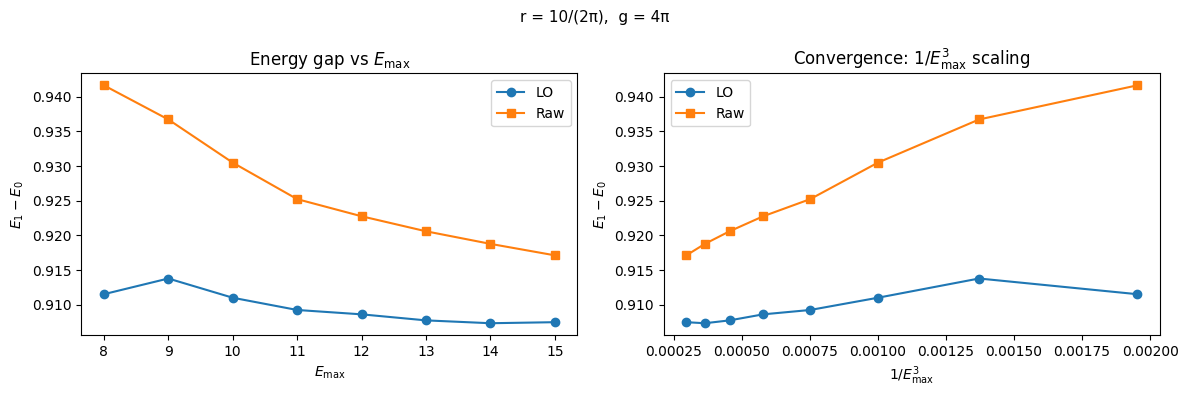

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

emax_vals = [row['e_max'] for row in scan_fixed]
gap_LO  = [row['eigs_LO'][1]  - row['eigs_LO'][0]  for row in scan_fixed if len(row['eigs_LO'])  > 1]
gap_raw = [row['eigs_raw'][1] - row['eigs_raw'][0] for row in scan_fixed if len(row['eigs_raw']) > 1]

axes[0].plot(emax_vals, gap_LO,  'o-', label='LO')
axes[0].plot(emax_vals, gap_raw, 's-', label='Raw')
axes[0].set_xlabel('$E_\\mathrm{max}$')
axes[0].set_ylabel('$E_1 - E_0$')
axes[0].set_title('Energy gap vs $E_\\mathrm{max}$')
axes[0].legend()

axes[1].plot([1/e**3 for e in emax_vals], gap_LO,  'o-', label='LO')
axes[1].plot([1/e**3 for e in emax_vals], gap_raw, 's-', label='Raw')
axes[1].set_xlabel('$1/E_\\mathrm{max}^3$')
axes[1].set_ylabel('$E_1 - E_0$')
axes[1].set_title('Convergence: $1/E_\\mathrm{max}^3$ scaling')
axes[1].legend()

fig.suptitle(f'r = 10/(2π),  g = 4π', fontsize=11)
fig.tight_layout()

#Agrees with https://arxiv.org/pdf/2110.08273 Figure 2.

## 8. Volume scan — even sector (main result)

Scan both $r$ (volume) and $E_\mathrm{max}$ using the **even-parity** zero-momentum basis.
For each volume we track $E_1^+ - E_0$ to see how quickly the gap converges with $E_\mathrm{max}$.

Note the zero eigenvalue of the even states is the same (numerically within errors here) as the zero eigenvalue of all states, i.e. E0. Note this is not the case for the odd states.

This is the main computation and may take a few minutes for the larger parameters.


In [ ]:
m, g = 1.0, 4*math.pi
n_eigens = 10
rN_values   = range(8, 12, 2)   #  →  r = rN/(2π)
emax_values = range(13, 17)      # e_max = 13 … 16

all_results = {}  # all_results[rN] = list of dicts per e_max

for rN in rN_values:
    r = rN / (2*math.pi)
    results = []
    for e_max in emax_values:
        lmax    = 100 * e_max
        lmaxeff = effective_lmax(lmax, e_max, m, r)
        gen_omega_list(lmaxeff + 1, m, r)

        #Even basis states:
        ebasis = basis_even(basis_l0(make_basis(lmaxeff, e_max, m, r)))
        ebasis.sort()
        en = len(ebasis)

        eH0   = h0(lmaxeff, e_max, m, r, ebasis)
        eH2   = delta_h2(lmaxeff, e_max, m, r, ebasis)
        eH4   = (1/r)*(1/(8*math.pi)) * delta_h4(lmaxeff, e_max, m, r, ebasis)

        eH_raw = eH0 + (g/24)*eH4
        eH_LO = eH0 + (1/4)*mv2_sq(e_max, m, r, g, l_uv)*eH2 + 1/24*(g + lambda2(e_max, m, r, g, l_uv))*eH4 #See https://arxiv.org/pdf/2507.15941 Eq. (2.43)



        k = min(n_eigens, en) 
        eigs_raw = compute_eigenvalues(eH_raw,    k)
        eigs_LO  = compute_eigenvalues(eH_LO,     k)
        results.append({'e_max': e_max, 'lmaxeff': lmaxeff, 'n_basis': en,
                        'eigs_LO': eigs_LO, 'eigs_raw': eigs_raw}) 
        print(f'rN={rN:2d}  e_max={e_max:2d}  lmaxeff={lmaxeff:3d}  basis size={en}')
    all_results[rN] = results


rN= 8  e_max=13  lmaxeff=  8  basis size=373
rN= 8  e_max=14  lmaxeff=  8  basis size=575
rN= 8  e_max=15  lmaxeff=  9  basis size=906
rN= 8  e_max=16  lmaxeff= 10  basis size=1407
rN=10  e_max=13  lmaxeff= 10  basis size=880
rN=10  e_max=14  lmaxeff= 11  basis size=1478
rN=10  e_max=15  lmaxeff= 11  basis size=2457
rN=10  e_max=16  lmaxeff= 12  basis size=4016


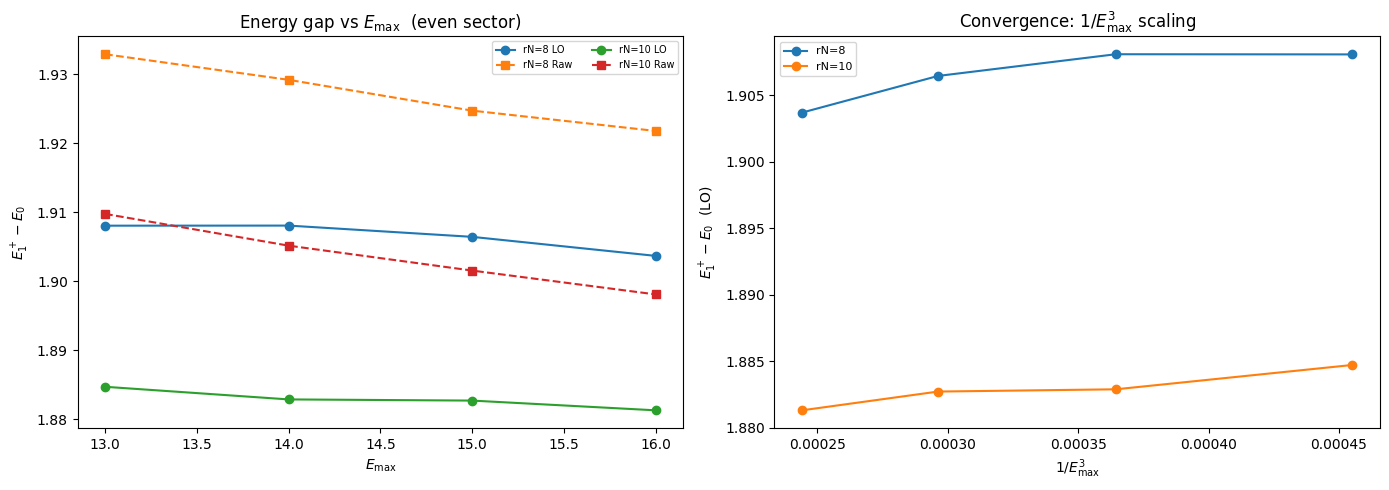

In [ ]:
# Energy gap E1+-E0 vs E_max for each volume
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for rN, results in all_results.items():
    emax_vals = [r['e_max'] for r in results]
    gap_LO    = [r['eigs_LO'][1]  - r['eigs_LO'][0]  for r in results if len(r['eigs_LO'])  > 1]
    gap_raw   = [r['eigs_raw'][1] - r['eigs_raw'][0] for r in results if len(r['eigs_raw']) > 1]
    label = f'rN={rN}'
    axes[0].plot(emax_vals, gap_LO,  'o-',  label=f'{label} LO')
    axes[0].plot(emax_vals, gap_raw, 's--', label=f'{label} Raw')
    axes[1].plot([1/e**3 for e in emax_vals], gap_LO, 'o-', label=label)

axes[0].set_xlabel('$E_\\mathrm{max}$')
axes[0].set_ylabel('$E_1^+ - E_0$')
axes[0].set_title('Energy gap vs $E_\\mathrm{max}$  (even sector)')
axes[0].legend(fontsize=7, ncol=2)

axes[1].set_xlabel('$1/E_\\mathrm{max}^3$')
axes[1].set_ylabel('$E_1^+ - E_0$  (LO)')
axes[1].set_title('Convergence: $1/E_\\mathrm{max}^3$ scaling')
axes[1].legend(fontsize=8)

fig.tight_layout()

#Agrees with figure 1 in https://arxiv.org/pdf/2507.15941 for rN=10

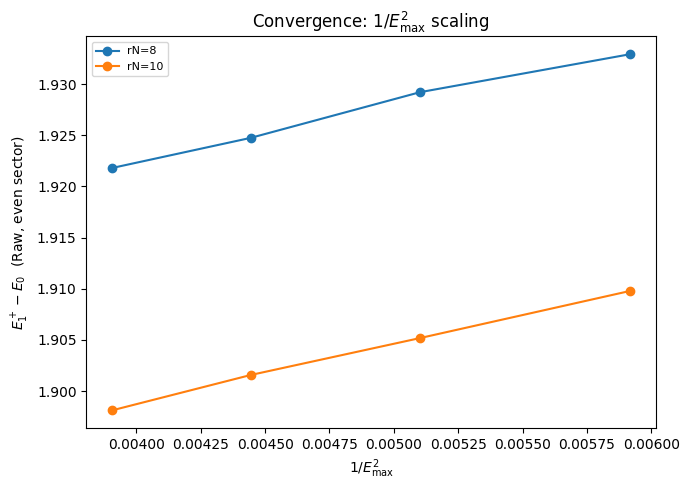

In [ ]:
# Same data on 1/E_max^2 axis for Raw gap
fig, ax = plt.subplots(figsize=(7, 5))

for rN, results in all_results.items():
    emax_vals = [r['e_max'] for r in results]
    gap_raw   = [r['eigs_raw'][1] - r['eigs_raw'][0] for r in results if len(r['eigs_raw']) > 1]
    ax.plot([1/e**2 for e in emax_vals], gap_raw, 'o-', label=f'rN={rN}')

ax.set_xlabel('$1/E_\\mathrm{max}^2$')
ax.set_ylabel('$E_1^+ - E_0$  (Raw, even sector)')
ax.set_title('Convergence: $1/E_\\mathrm{max}^2$ scaling')
ax.legend(fontsize=8)
fig.tight_layout()


## 9. Volume scan — odd sector 

Scan both $r$ (volume) and $E_\mathrm{max}$ using the **odd-parity** zero-momentum basis.
For each volume we track $E_1^- - E_0$ to see how quickly the gap converges with $E_\mathrm{max}$.

In [ ]:
m, g = 1.0, 4*math.pi
n_eigens = 10
rN_values   = range(8, 12, 2)   #  →  r = rN/(2π)
emax_values = range(13, 17)      # e_max = 13 … 16

all_results = {}  # all_results[rN] = list of dicts per e_max

for rN in rN_values:
    r = rN / (2*math.pi)
    results = []
    for e_max in emax_values:
        lmax    = 100 * e_max
        lmaxeff = effective_lmax(lmax, e_max, m, r)
        gen_omega_list(lmaxeff + 1, m, r)

        #Find the ground state energy:
        basis = basis_l0(make_basis(lmaxeff, e_max, m, r))
        basis.sort()
        n = len(basis)

        H0   = h0(lmaxeff, e_max, m, r, basis)
        H2   = delta_h2(lmaxeff, e_max, m, r, basis)
        H4   = (1/r)*(1/(8*math.pi)) * delta_h4(lmaxeff, e_max, m, r, basis)

        H_raw = H0 + (g/24)*H4
        H_LO = H0 + (1/4)*mv2_sq(e_max, m, r, g, l_uv)*H2 + 1/24*(g + lambda2(e_max, m, r, g, l_uv))*H4 #See https://arxiv.org/pdf/2507.15941 Eq. (2.43)

        E0_raw = compute_eigenvalues(H_raw,    1)
        E0_LO  = compute_eigenvalues(H_LO,     1)

        #Odd basis states:
        obasis = basis_odd(basis_l0(make_basis(lmaxeff, e_max, m, r)))
        obasis.sort()
        on = len(obasis)

        oH0   = h0(lmaxeff, e_max, m, r, obasis)
        oH2   = delta_h2(lmaxeff, e_max, m, r, obasis)
        oH4   = (1/r)*(1/(8*math.pi)) * delta_h4(lmaxeff, e_max, m, r, obasis)
        oH_raw = oH0 + (g/24)*oH4
        oH_LO = oH0 + (1/4)*mv2_sq(e_max, m, r, g, l_uv)*oH2 + 1/24*(g + lambda2(e_max, m, r, g, l_uv))*oH4 #See https://arxiv.org/pdf/2507.15941 Eq. (2.43)


        k = min(n_eigens, on) 
        eigs_raw = compute_eigenvalues(oH_raw,    k)
        eigs_LO  = compute_eigenvalues(oH_LO,     k)
        results.append({'e_max': e_max, 'lmaxeff': lmaxeff, 'n_basis': on,
                        'eigs_LO': eigs_LO, 'eigs_raw': eigs_raw, 'E0_LO': E0_LO, 'E0_raw': E0_raw})
        print(f'rN={rN:2d}  e_max={e_max:2d}  lmaxeff={lmaxeff:3d}  basis size={on}')
    all_results[rN] = results


rN= 8  e_max=13  lmaxeff=  8  basis size=372
rN= 8  e_max=14  lmaxeff=  8  basis size=593
rN= 8  e_max=15  lmaxeff=  9  basis size=903
rN= 8  e_max=16  lmaxeff= 10  basis size=1374
rN=10  e_max=13  lmaxeff= 10  basis size=908
rN=10  e_max=14  lmaxeff= 11  basis size=1500


KeyboardInterrupt: 

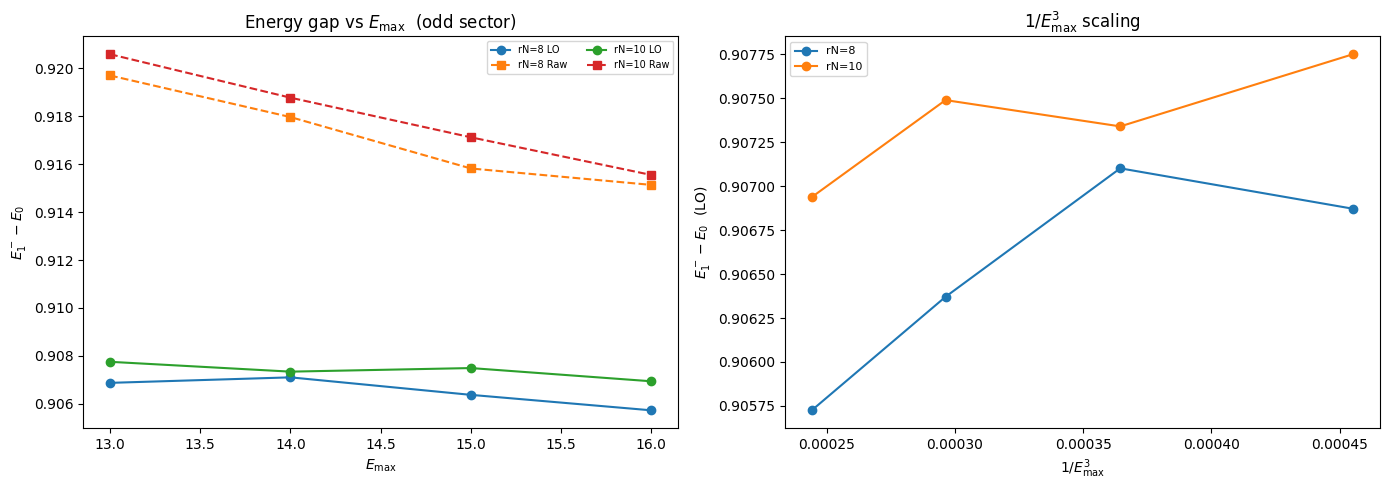

In [ ]:
# Energy gap E1--E0 vs E_max for each volume
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for rN, results in all_results.items():
    emax_vals = [r['e_max'] for r in results]
    gap_LO    = [r['eigs_LO'][0]-r['E0_LO'][0]  for r in results if len(r['eigs_LO'])  > 1]
    gap_raw   = [r['eigs_raw'][0]-r['E0_raw'][0] for r in results if len(r['eigs_raw']) > 1]
    label = f'rN={rN}'
    axes[0].plot(emax_vals, gap_LO,  'o-',  label=f'{label} LO')
    axes[0].plot(emax_vals, gap_raw, 's--', label=f'{label} Raw')
    axes[1].plot([1/e**3 for e in emax_vals], gap_LO, 'o-', label=label)

axes[0].set_xlabel('$E_\\mathrm{max}$')
axes[0].set_ylabel('$E_1^- - E_0$')
axes[0].set_title('Energy gap vs $E_\\mathrm{max}$  (odd sector)')
axes[0].legend(fontsize=7, ncol=2)

axes[1].set_xlabel('$1/E_\\mathrm{max}^3$')
axes[1].set_ylabel('$E_1^- - E_0$  (LO)')
axes[1].set_title('$1/E_\\mathrm{max}^3$ scaling')
axes[1].legend(fontsize=8)

fig.tight_layout()


# Almost agrees with eg https://arxiv.org/pdf/2507.15941 eg Figure 2, but that includes NLO correction which we don't have. 